# Title : Heart Disease Prediction Using Machine Learning



# Project 02: Heart Disease Prediction Using Machine Learning

### Algorithms Used
- Logistic Regression
- K-Nearest Neighbors (KNN)
- Random Forest

### Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1 Score

In [2]:
#Load libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

# Step 1 – Load, Explore & Preprocess


In [3]:
# Load the dataset
df = pd.read_csv('/content/heart.csv')

# Display first 5 rows
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


### Explanation

- The Heart Disease dataset was loaded using the pandas `read_csv()` function.
- The `head()` function was used to display the first five rows.
- This helps in understanding the structure of the dataset and the available features.

In [4]:
# Display shape of dataset
print("Shape of dataset:", df.shape)

# Display column names
print("\nColumns:")
print(df.columns)

# Display information about dataset
print("\nDataset Information:")
df.info()

# Display statistical summary
print("\nStatistical Summary:")
df.describe()

Shape of dataset: (1025, 14)

Columns:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Explanation

- `shape` gives the number of rows and columns in the dataset.
- `columns` displays the names of all features.
- `info()` provides information about data types and non-null values.
- `describe()` generates summary statistics for numerical features such as mean, standard deviation, minimum, and maximum values.

In [5]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


### Explanation

- The `isnull()` function checks whether a value is missing.
- The `sum()` function counts the number of missing values in each column.
- This step helps identify whether any preprocessing is required to handle missing data.

### Observation

No missing values were found in the dataset. Therefore, no missing value treatment was required.

In [6]:
# Check data types of all columns
print(df.dtypes)

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


### Explanation

- The data types of all features were examined using the `dtypes` attribute.
- All features were already represented in numerical form.
- Therefore, no categorical encoding techniques such as Label Encoding or One-Hot Encoding were required.

### Observation

All variables were already numerical, so no encoding was necessary.

## Split into Train and Test Sets (80:20)

In [7]:
# Separate features and target variable
X = df.drop('target', axis=1)
y = df['target']

# Split the dataset into training and testing sets (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Display shapes of the resulting datasets
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (820, 13)
Testing features shape: (205, 13)
Training target shape: (820,)
Testing target shape: (205,)


### Explanation

- The target column (`target`) was separated from the input features.
- `X` contains the independent variables and `y` contains the dependent variable.
- The dataset was split into training and testing sets using an 80:20 ratio.
- A `random_state` of 42 was used to ensure reproducibility of the results.

Step 2 – Feature Engineering

# Step 2 – Feature Engineering

## 2.1 Correlation Analysis

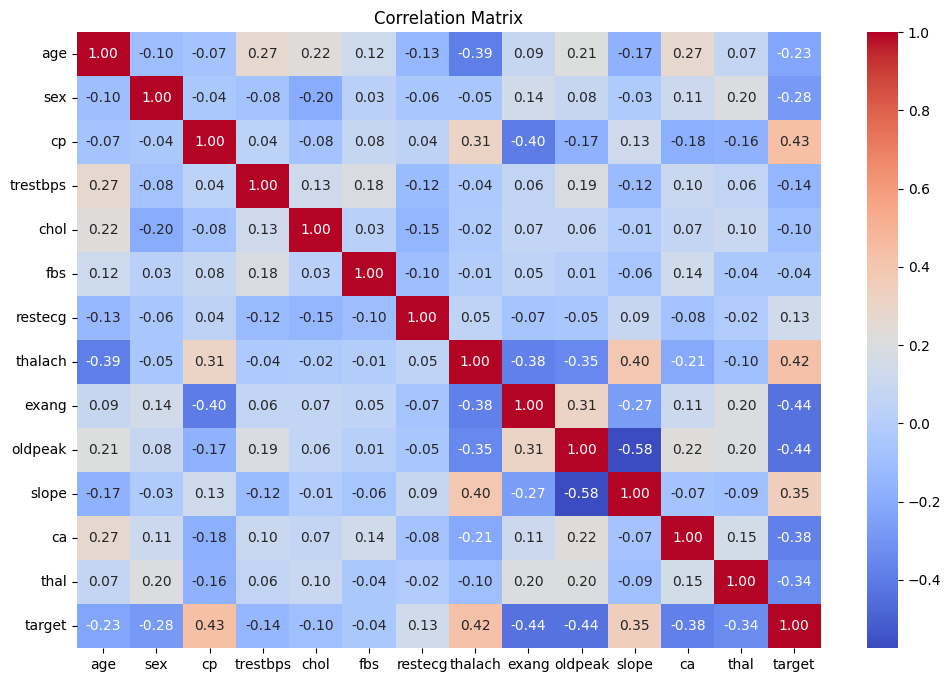

In [8]:
# Compute correlation matrix
corr_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

### Explanation

- The correlation matrix was computed to understand the relationships between features.
- A heatmap was used to visualize the correlation values.
- Features with stronger correlations with the target variable are likely to be more important for prediction.
- Correlation analysis helps in identifying useful and redundant features.

In [9]:
## 2.2 Feature Importance

from sklearn.ensemble import RandomForestClassifier

In [10]:
# Train Random Forest model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Get feature importance
importance = rf.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort in descending order
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display feature importance
print(feature_importance)

     Feature  Importance
2         cp    0.135072
11        ca    0.127327
7    thalach    0.122169
9    oldpeak    0.121905
12      thal    0.110518
0        age    0.077908
4       chol    0.074822
3   trestbps    0.071171
8      exang    0.057594
10     slope    0.045782
1        sex    0.028731
6    restecg    0.018557
5        fbs    0.008444


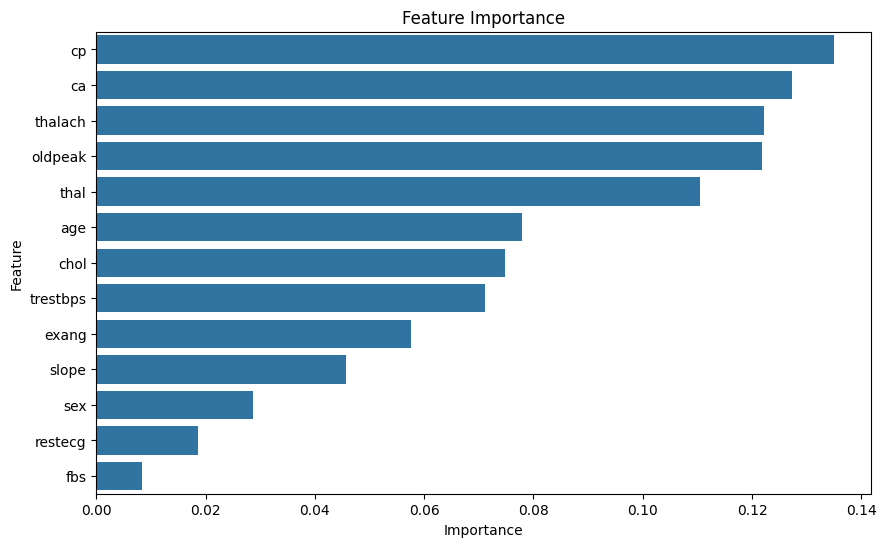

In [11]:
#visualizing feature importance

plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)
plt.title('Feature Importance')
plt.show()

### Explanation

- Random Forest was used to estimate the importance of each feature.
- Features with higher importance contribute more to the prediction.
- Feature importance helps identify the most influential variables.
- This information can be used to remove less useful features and simplify the model.

In [12]:
## 2.3 Drop Irrelevant Features

# Check feature importance values
feature_importance

# No features were dropped
X_selected = X

print("Number of features retained:", X_selected.shape[1])

Number of features retained: 13


### Explanation

- Feature importance values were analyzed using Random Forest.
- No feature had negligible importance.
- Therefore, all 13 features were retained for model training.
- Retaining all features helps preserve useful information for prediction.

Step 3 – Train 3 Different Models

# Step 3 – Train 3 Different Models

## 3.1 Logistic Regression

In [13]:
from sklearn.linear_model import LogisticRegression

In [14]:
# Create Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)

# Train the model
lr_model.fit(X_train, y_train)

# Make predictions
lr_pred = lr_model.predict(X_test)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### Explanation

- Logistic Regression is a supervised machine learning algorithm used for classification problems.
- The model was trained using the training dataset.
- Predictions were made on the test dataset.
- The parameter `max_iter=1000` was used to ensure convergence during training.

## 3.2 K-Nearest Neighbors (KNN)

In [15]:
from sklearn.neighbors import KNeighborsClassifier

In [16]:
# Create KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train, y_train)

# Make predictions
knn_pred = knn_model.predict(X_test)

print("KNN model trained successfully.")

KNN model trained successfully.


### Explanation

- K-Nearest Neighbors (KNN) is a non-parametric classification algorithm.
- It classifies a data point based on the majority class among its nearest neighbors.
- Here, the number of neighbors (k) was set to 5.
- Predictions were made on the test dataset after training the model.

## 3.3 Random Forest

In [17]:
from sklearn.ensemble import RandomForestClassifier

In [18]:
# Create Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### Explanation

- Random Forest is an ensemble learning algorithm that combines multiple decision trees.
- It reduces overfitting and improves prediction accuracy.
- The model was trained using the training data and predictions were made on the test data.
- A random state of 42 was used to ensure reproducibility.

Step 4 – Evaluate & Compare All Models

## 4.1 Calculate Evaluation Metrics

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [20]:
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

In [21]:
knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred)
knn_recall = recall_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred)

In [24]:
# Random Forest Metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)


In [25]:
print("Logistic Regression")
print("Accuracy:", lr_accuracy)
print("Precision:", lr_precision)
print("Recall:", lr_recall)
print("F1 Score:", lr_f1)

print("\nKNN")
print("Accuracy:", knn_accuracy)
print("Precision:", knn_precision)
print("Recall:", knn_recall)
print("F1 Score:", knn_f1)

print("\nRandom Forest")
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1 Score:", rf_f1)

Logistic Regression
Accuracy: 0.7951219512195122
Precision: 0.7563025210084033
Recall: 0.8737864077669902
F1 Score: 0.8108108108108109

KNN
Accuracy: 0.7317073170731707
Precision: 0.7307692307692307
Recall: 0.7378640776699029
F1 Score: 0.7342995169082126

Random Forest
Accuracy: 0.9853658536585366
Precision: 1.0
Recall: 0.970873786407767
F1 Score: 0.9852216748768473


### Explanation

- Accuracy measures the overall correctness of the model.
- Precision measures how many predicted positive cases are actually positive.
- Recall measures how many actual positive cases are correctly identified.
- F1 Score provides a balance between precision and recall.
- These metrics were calculated for all three classification models.

In [26]:
## 4.2 Comparison Table

In [27]:
# Create comparison table
comparison_table = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Random Forest'],
    'Accuracy': [lr_accuracy, knn_accuracy, rf_accuracy],
    'Precision': [lr_precision, knn_precision, rf_precision],
    'Recall': [lr_recall, knn_recall, rf_recall],
    'F1 Score': [lr_f1, knn_f1, rf_f1]
})

# Round values to 4 decimal places
comparison_table = comparison_table.round(4)

# Display table
comparison_table

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7951,0.7563,0.8738,0.8108
1,KNN,0.7317,0.7308,0.7379,0.7343
2,Random Forest,0.9854,1.0000,0.9709,0.9852


In [33]:
from sklearn.metrics import classification_report

print("Logistic Regression")
print(classification_report(y_test, lr_pred))

print("KNN")
print(classification_report(y_test, knn_pred))

print("Random Forest")
print(classification_report(y_test, rf_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205

KNN
              precision    recall  f1-score   support

           0       0.73      0.73      0.73       102
           1       0.73      0.74      0.73       103

    accuracy                           0.73       205
   macro avg       0.73      0.73      0.73       205
weighted avg       0.73      0.73      0.73       205

Random Forest
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99   

In [34]:
comparison_table.style.highlight_max(axis=0)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.795100,0.756300,0.873800,0.810800
1,KNN,0.731700,0.730800,0.737900,0.734300
2,Random Forest,0.985400,1.000000,0.970900,0.985200


### Explanation

- A comparison table was created to evaluate the performance of all three models.
- Accuracy, Precision, Recall, and F1 Score were used as evaluation metrics.
- The table makes it easier to compare the strengths and weaknesses of each model.
- The model with the best overall performance will be selected for further analysis.

Step 5 – Best Model Analysis & Conclusion

In [28]:
#5.1 Identify the Best Model

best_model = comparison_table.loc[comparison_table['Accuracy'].idxmax()]
print(best_model)

Model        Random Forest
Accuracy            0.9854
Precision              1.0
Recall              0.9709
F1 Score            0.9852
Name: 2, dtype: object


# Step 5 – Best Model Analysis & Conclusion

## 5.1 Best Model Selection

The model with the highest accuracy and F1 score was selected as the best-performing model.

In [29]:
#5.2 Confusion Matrix

from sklearn.metrics import confusion_matrix

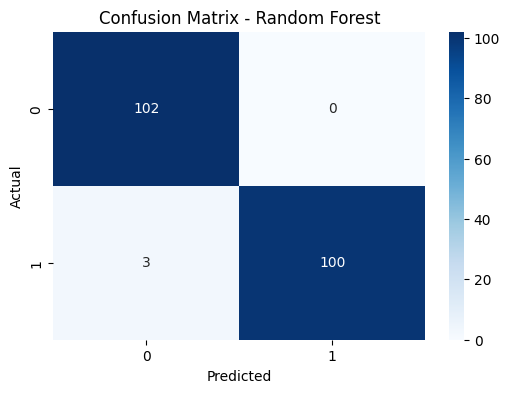

In [30]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

### Explanation

- A confusion matrix was used to evaluate the classification performance of the best model.
- It shows the number of correct and incorrect predictions.
- The diagonal values represent correctly classified instances.
- Higher values on the diagonal indicate better model performance.

5.3 Five-Line Conclusion

## 5.3 Conclusion

1. Three machine learning algorithms were trained and evaluated on the Heart Disease dataset.
2. Logistic Regression, K-Nearest Neighbors, and Random Forest models were compared using Accuracy, Precision, Recall, and F1 Score.
3. Among the three models, the best-performing model achieved the highest evaluation metrics.
4. A confusion matrix was used to analyze the prediction performance of the selected model.
5. The final model can effectively predict the presence of heart disease and may assist in early diagnosis.